# Chapter 1 — Why Programmers Should Learn Mathematics

> **Prerequisites:** None. This is the opening chapter.
>
> **You will learn:**
> - What mathematics actually is (not what school made it seem)
> - Where mathematical thinking gives programmers a concrete advantage
> - How to measure the gap in your own mathematical background
> - What this book will and will not do
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Mathematics is the study of **structure**. Not numbers specifically — structure. A number is one kind of structure. A graph is another. A probability distribution is another. A neural network's weight matrix is another.

The reason programmers should learn mathematics is not to pass interviews, use fancier libraries, or appear more credible. It is this:

> **Mathematical training teaches you to see the shape of a problem before touching code.**

Without it, you solve problems by trial and error at the implementation level. With it, you solve problems at the structural level first — which is faster, more reliable, and more transferable.

Three concrete examples:

**1. Debugging.** A programmer without math intuition debugs by changing code. A programmer with math intuition asks: *what invariant is being violated?* That question cuts debugging time in half.

**2. Algorithm design.** Many algorithms that look like magic are applications of one mathematical idea. Knowing that idea means you can *derive* the algorithm rather than memorize it. Binary search, FFT, backpropagation — all derivable from first principles if you have the right math.

**3. Machine learning.** ML is applied mathematics. If you cannot read the math, you are using tools you cannot reason about. That is a ceiling that becomes painful quickly.

**Common misconception:** "I use libraries, so I don't need to understand the math underneath."

This is true until it isn't. Libraries work until your data is unusual, your model misbehaves, your optimization diverges, or you need to do something the library doesn't support. At that point, math is not optional.

## 2. Intuition & Mental Models

**Physical analogy:** Think of mathematics as the specification language for reality. Physics doesn't describe the universe in English — it describes it in differential equations. Biology uses probability theory. Economics uses optimization. Mathematics is the substrate everything sits on.

**Computational analogy:** Think of a type system. A weakly-typed language lets you write `"3" + 3` and get unpredictable results. A strongly-typed language forces you to be explicit about what kind of thing you are manipulating — and catches whole classes of bugs at compile time. Mathematics is the ultimate type system for ideas. It forces you to state *exactly* what you mean, and it catches logical errors before you run anything.

**The gap model:** Your mathematical knowledge is not zero. It is distributed unevenly. You likely have:
- Strong: arithmetic, basic algebra, loops-as-sequences, boolean logic
- Weak: rigorous function theory, linear algebra, probability
- Missing: calculus intuition, proof structure, mathematical abstraction

This book fills the weak and missing categories systematically.

## 3. Visualization

The following plots map two things: (a) where different mathematical concepts appear in a programmer's typical work, and (b) the dependency structure — which concepts require which others.

This is not the full dependency graph of mathematics. It is the specific subgraph relevant to this book's goal: building the math needed to understand modern AI and data systems.

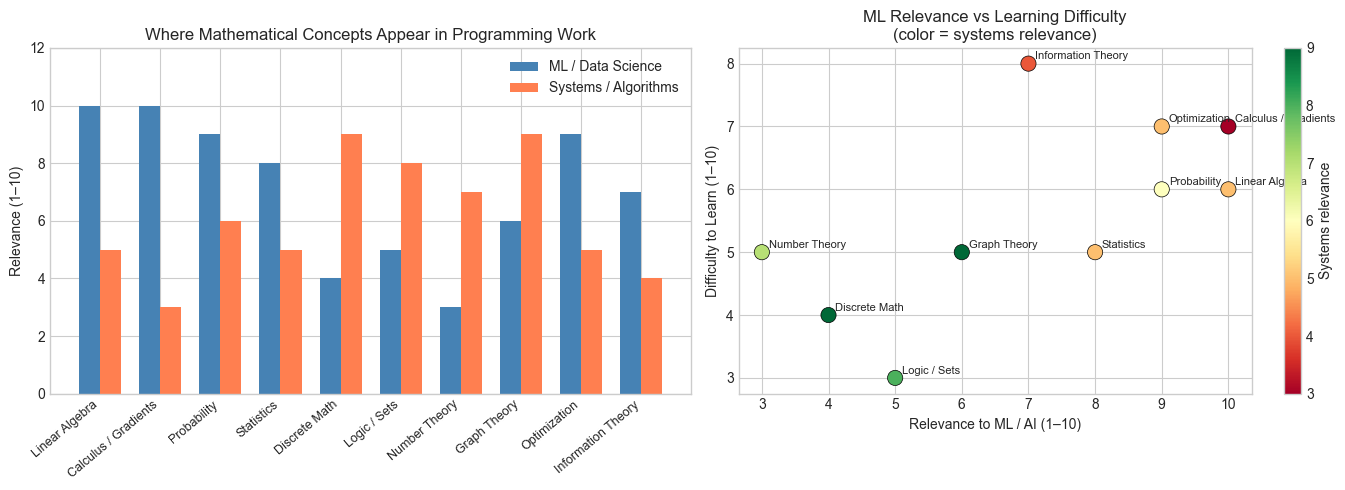

Insight: Linear algebra and calculus are both highly relevant AND moderately difficult.
They are the best return-on-investment targets for a programmer learning math.


In [1]:
# --- Visualization: Math concepts and where they appear in programming work ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.style.use('seaborn-v0_8-whitegrid')

# Data: (concept, frequency_in_ml_work, frequency_in_systems_work, difficulty_to_learn)
# Scores are qualitative 1-10
concepts = [
    'Linear Algebra',
    'Calculus / Gradients',
    'Probability',
    'Statistics',
    'Discrete Math',
    'Logic / Sets',
    'Number Theory',
    'Graph Theory',
    'Optimization',
    'Information Theory',
]
ml_relevance    = [10, 10, 9, 8, 4, 5, 3, 6, 9, 7]
systems_relevance = [5, 3, 6, 5, 9, 8, 7, 9, 5, 4]
difficulty      = [6, 7, 6, 5, 4, 3, 5, 5, 7, 8]

x = np.arange(len(concepts))
WIDTH = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: relevance by domain
bars1 = axes[0].bar(x - WIDTH/2, ml_relevance, WIDTH, label='ML / Data Science', color='steelblue')
bars2 = axes[0].bar(x + WIDTH/2, systems_relevance, WIDTH, label='Systems / Algorithms', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(concepts, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Relevance (1–10)')
axes[0].set_title('Where Mathematical Concepts Appear in Programming Work')
axes[0].legend()
axes[0].set_ylim(0, 12)

# Right: relevance vs difficulty scatter
scatter = axes[1].scatter(ml_relevance, difficulty, s=120, c=systems_relevance,
                           cmap='RdYlGn', edgecolors='black', linewidth=0.5)
for i, name in enumerate(concepts):
    axes[1].annotate(name, (ml_relevance[i], difficulty[i]),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_xlabel('Relevance to ML / AI (1–10)')
axes[1].set_ylabel('Difficulty to Learn (1–10)')
axes[1].set_title('ML Relevance vs Learning Difficulty\n(color = systems relevance)')
plt.colorbar(scatter, ax=axes[1], label='Systems relevance')

plt.tight_layout()
plt.show()

print("Insight: Linear algebra and calculus are both highly relevant AND moderately difficult.")
print("They are the best return-on-investment targets for a programmer learning math.")

## 4. Mathematical Formulation

This chapter does not introduce new mathematical notation. Instead, it establishes the *meta-framework* for how mathematics will be presented throughout the book.

**Definition (informal):** Mathematics is a formal system for deriving true statements from axioms using rules of inference.

For this book's purposes, the practical definition is:

> Mathematics is the set of techniques for describing relationships between quantities, structures, or operations with enough precision that the relationships can be *verified*, *generalized*, and *computed*.

Three key properties of a good mathematical description:

1. **Precision:** Every symbol has an unambiguous meaning.
2. **Generality:** The description applies to a *class* of objects, not just one instance.
3. **Computability:** There exists a procedure (even if impractical) to verify the claim.

As a programmer, you already write things with property 1 (code is precise). Property 2 is where mathematics extends beyond programming — generic types and polymorphism are early steps toward it, but mathematics goes much further. Property 3 connects mathematics back to computation.

**The bridge:** A mathematical formula is a compressed program. The formula:

$$\sum_{k=1}^{n} k = \frac{n(n+1)}{2}$$

is *both* a statement about numbers *and* an O(1) algorithm for summing 1 to n. The left side is a loop; the right side is its closed-form equivalent. Math is the discipline of finding the right side.

In [2]:
# --- Implementation: Formula as compressed program ---
# The sum formula above — two implementations, same result

def sum_loop(n):
    """
    Sum 1..n via explicit loop. O(n) time.
    
    Args:
        n: positive integer
    Returns:
        Sum of integers from 1 to n
    """
    total = 0
    for k in range(1, n + 1):
        total += k
    return total

def sum_formula(n):
    """
    Sum 1..n via closed-form formula. O(1) time.
    
    Formula: n * (n + 1) / 2
    Where n = upper bound of summation.
    
    Args:
        n: positive integer
    Returns:
        Sum of integers from 1 to n
    """
    return n * (n + 1) // 2

# Verify they agree
test_values = [1, 5, 10, 100, 1000, 10000]
print(f"{'n':>8}  {'loop':>10}  {'formula':>10}  {'match':>6}")
print("-" * 42)
for n in test_values:
    loop_result    = sum_loop(n)
    formula_result = sum_formula(n)
    print(f"{n:>8}  {loop_result:>10}  {formula_result:>10}  {str(loop_result == formula_result):>6}")

print()
print("The formula is not a shortcut. It IS the loop — rewritten in mathematical form.")
print("Mathematics is the discipline of making such rewrites.")

       n        loop     formula   match
------------------------------------------
       1           1           1    True
       5          15          15    True
      10          55          55    True
     100        5050        5050    True
    1000      500500      500500    True
   10000    50005000    50005000    True

The formula is not a shortcut. It IS the loop — rewritten in mathematical form.
Mathematics is the discipline of making such rewrites.


## 5. Python Implementation

No standalone implementation this chapter — the concept is meta-level. Instead, we build a **self-diagnostic tool**: a program that estimates the reader's mathematical starting point by probing their comfort with specific operations.

In [3]:
# --- Implementation: Mathematical familiarity diagnostic ---
# Run this. Answer honestly. It shapes how you should pace through the book.

import numpy as np

# Rate your comfort: 0 = never heard of it, 1 = seen it, 2 = used it, 3 = fluent
# Edit the numbers below to reflect your honest self-assessment

COMFORT = {
    # Part I concepts
    'Boolean logic and truth tables':          3,  # <-- edit this
    'Set notation (∈, ∪, ∩, ⊆)':             1,
    'Mathematical proof by induction':         0,
    'Function notation f: A → B':             2,
    
    # Part II-III concepts
    'Modular arithmetic':                      2,
    'Logarithms and their properties':         2,
    'Floating-point representation':           1,
    'Function composition and inversion':      2,
    
    # Part IV-V concepts
    'Dot product of two vectors':              1,
    'Trigonometry (sin, cos, unit circle)':    2,
    'Geometric transformations (rotate/scale)': 1,
    
    # Part VI concepts
    'Matrix multiplication':                   1,
    'Eigenvalues and eigenvectors':            0,
    'Singular value decomposition (SVD)':      0,
    
    # Part VII concepts
    'Derivatives and the chain rule':          1,
    'Gradient descent':                        2,
    'Integration as area under a curve':       1,
    
    # Part VIII-IX concepts
    'Conditional probability and Bayes':       1,
    'Normal distribution and variance':        2,
    'Hypothesis testing and p-values':         1,
}

# Compute diagnostic
scores = np.array(list(COMFORT.values()))
max_score = 3 * len(scores)
pct = 100 * scores.sum() / max_score

weak = [k for k, v in COMFORT.items() if v <= 1]
strong = [k for k, v in COMFORT.items() if v == 3]

print(f"Mathematical readiness: {pct:.0f}%  ({scores.sum()} / {max_score} points)")
print()
print(f"Strong areas ({len(strong)}):")
for s in strong:
    print(f"  ✓ {s}")
print()
print(f"Areas to build ({len(weak)}):")
for w in weak:
    print(f"  → {w}")
print()
if pct < 30:
    print("Recommendation: Work through every chapter. Do not skip.")
elif pct < 60:
    print("Recommendation: Read all chapters, but you can move faster through familiar areas.")
else:
    print("Recommendation: Skim familiar chapters, focus on gaps. Do all projects.")

Mathematical readiness: 43%  (26 / 60 points)

Strong areas (1):
  ✓ Boolean logic and truth tables

Areas to build (12):
  → Set notation (∈, ∪, ∩, ⊆)
  → Mathematical proof by induction
  → Floating-point representation
  → Dot product of two vectors
  → Geometric transformations (rotate/scale)
  → Matrix multiplication
  → Eigenvalues and eigenvectors
  → Singular value decomposition (SVD)
  → Derivatives and the chain rule
  → Integration as area under a curve
  → Conditional probability and Bayes
  → Hypothesis testing and p-values

Recommendation: Read all chapters, but you can move faster through familiar areas.


## 6. Experiments

These experiments are about *observation*, not computation. They are designed to show you mathematical structure that already exists in your code.

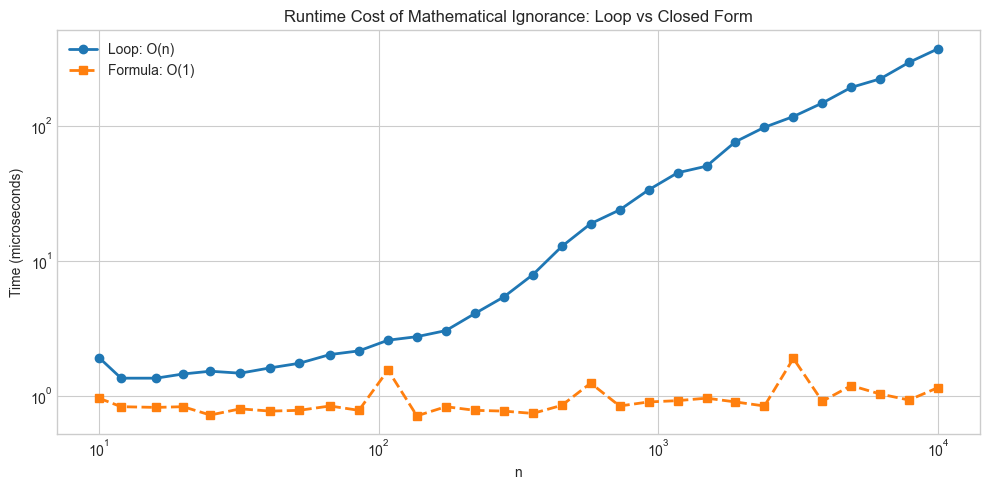

At n=10000, the formula is 323x faster.


In [4]:
# --- Experiment 1: The cost of mathematical ignorance ---
# Hypothesis: A naive implementation of a mathematical relationship is
# systematically slower than a mathematically-informed one.
# Try changing: N_MAX to see how the gap grows

import time
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

N_MAX = 10000  # <-- try changing this: 1000, 50000, 100000
REPS = 10  # repetitions for timing stability

ns = np.logspace(1, np.log10(N_MAX), 30, dtype=int)
loop_times = []
formula_times = []

for n in ns:
    # Time the loop
    t0 = time.perf_counter()
    for _ in range(REPS):
        sum(range(1, n + 1))
    loop_times.append((time.perf_counter() - t0) / REPS * 1e6)  # microseconds
    
    # Time the formula
    t0 = time.perf_counter()
    for _ in range(REPS):
        _ = n * (n + 1) // 2
    formula_times.append((time.perf_counter() - t0) / REPS * 1e6)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(ns, loop_times, 'o-', label='Loop: O(n)', linewidth=2)
ax.loglog(ns, formula_times, 's--', label='Formula: O(1)', linewidth=2)
ax.set_xlabel('n')
ax.set_ylabel('Time (microseconds)')
ax.set_title('Runtime Cost of Mathematical Ignorance: Loop vs Closed Form')
ax.legend()
plt.tight_layout()
plt.show()

speedup = loop_times[-1] / formula_times[-1]
print(f"At n={ns[-1]}, the formula is {speedup:.0f}x faster.")

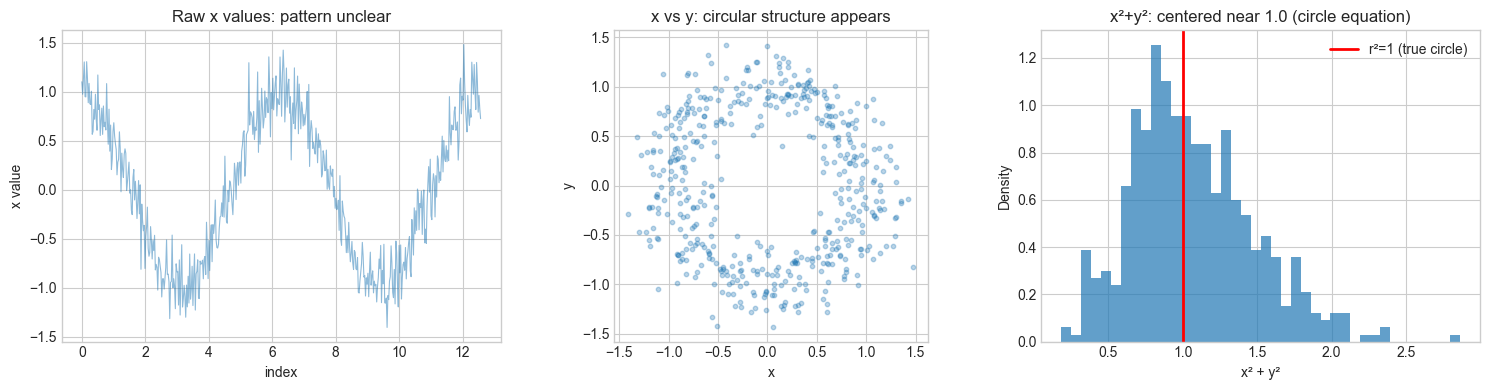

Mean of x²+y²: 1.0669  (expected: ~1.04 = 1 + noise variance)
The mathematical lens (x²+y²=1) reveals structure invisible in raw x or y.


In [5]:
# --- Experiment 2: Mathematical structure in data ---
# Hypothesis: Real data contains mathematical regularities that are invisible
# without the right lens.
# Try changing: N_SAMPLES, or replace the data generation with something of your own.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
N_SAMPLES = 500  # <-- try changing this

# Generate data with hidden structure
t = np.linspace(0, 4 * np.pi, N_SAMPLES)
x = np.cos(t) + 0.2 * np.random.randn(N_SAMPLES)  # noisy circle x
y = np.sin(t) + 0.2 * np.random.randn(N_SAMPLES)  # noisy circle y

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# View 1: raw x values over time — looks like noise
axes[0].plot(t, x, alpha=0.5, linewidth=0.8)
axes[0].set_xlabel('index')
axes[0].set_ylabel('x value')
axes[0].set_title('Raw x values: pattern unclear')

# View 2: x vs y — structure becomes visible
axes[1].scatter(x, y, alpha=0.3, s=10)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')
axes[1].set_title('x vs y: circular structure appears')

# View 3: x² + y² — mathematical lens reveals exact structure
r_squared = x**2 + y**2
axes[2].hist(r_squared, bins=40, density=True, alpha=0.7)
axes[2].axvline(x=1.0, color='red', linewidth=2, label='r²=1 (true circle)')
axes[2].set_xlabel('x² + y²')
axes[2].set_ylabel('Density')
axes[2].set_title('x²+y²: centered near 1.0 (circle equation)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Mean of x²+y²: {r_squared.mean():.4f}  (expected: ~1.04 = 1 + noise variance)")
print("The mathematical lens (x²+y²=1) reveals structure invisible in raw x or y.")

## 7. Exercises

**Easy 1.** The formula for the sum of first n integers is n(n+1)/2. Verify it for n=1, n=2, n=10, and n=100 using Python. *(Expected: matching integers)*

**Easy 2.** In the diagnostic code above, modify `COMFORT` to reflect your actual self-assessment. Which areas does the tool identify as weakest? Are those the areas you expected? *(Expected: printed list of weak areas)*

**Medium 1.** Experiment 1 measured the speedup of a closed-form formula over a loop. Repeat the experiment for a *different* mathematical identity: the sum of squares 1² + 2² + ... + n² = n(n+1)(2n+1)/6. Implement both a loop version and a formula version, time them, and plot the speedup. *(Hint: the structure of the code is identical to Experiment 1)*

**Medium 2.** Modify Experiment 2 to use an ellipse instead of a circle: x = 2cos(t), y = sin(t). What is the equation of an ellipse? What mathematical lens would reveal the structure in noisy ellipse data? Implement it. *(Hint: the circle equation is x²/r² + y²/r² = 1; what changes for an ellipse?)*

**Hard.** The Part I motivating problem showed that the sum of the first n odd numbers equals n². Write a *geometric* proof: draw a grid of dots where n² represents an n×n square, and show visually (in code) that adding the k-th odd number (2k-1) adds exactly an L-shaped border of dots to the (k-1)×(k-1) square. Implement the visualization for n=1 through n=6. *(Challenge: make the L-shaped additions clearly visible using different colors)*

## 8. Mini Project

**Mathematical Signature of a Sequence**

Problem: Given an unknown sequence of numbers, determine its mathematical character — linear, quadratic, exponential, or other — purely by analyzing its differences and ratios.

This is a fundamental technique in numerical mathematics: finite differences reveal the degree of a polynomial, and ratios reveal exponential growth. You do not need to know this formally yet — the code will show you.

In [6]:
# --- Mini Project: Mathematical Signature of a Sequence ---
# Problem: Given a sequence, classify its mathematical nature by computing
# differences (for polynomial) and ratios (for exponential).
# Dataset: generated sequences of known type
# Task: implement the classifier and test it on mystery sequences

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def finite_differences(seq, order=3):
    """
    Compute finite differences up to given order.
    
    The k-th finite difference of a degree-k polynomial is constant.
    
    Args:
        seq: 1D array of values
        order: number of difference levels to compute
    Returns:
        list of arrays: [seq, Δseq, Δ²seq, ...]
    """
    result = [np.array(seq, dtype=float)]
    for _ in range(order):
        result.append(np.diff(result[-1]))
    return result

def growth_ratios(seq):
    """
    Compute consecutive ratios seq[k+1] / seq[k].
    Constant ratio → exponential growth.
    
    Args:
        seq: 1D array of positive values
    Returns:
        Array of ratios (length = len(seq) - 1)
    """
    seq = np.array(seq, dtype=float)
    return seq[1:] / seq[:-1]

def classify_sequence(seq, tolerance=0.01):
    """
    Classify a sequence as linear, quadratic, cubic, exponential, or unknown.
    
    Strategy:
    - Check if k-th finite differences are approximately constant (polynomial degree k)
    - Check if growth ratios are approximately constant (exponential)
    
    Args:
        seq: 1D array of values
        tolerance: relative tolerance for 'approximately constant'
    Returns:
        Classification string
    """
    seq = np.array(seq, dtype=float)
    
    # Check finite differences
    diffs = finite_differences(seq, order=3)
    for k, d in enumerate(diffs[1:], start=1):  # skip original sequence
        if len(d) > 1:
            relative_variation = np.std(d) / (np.abs(np.mean(d)) + 1e-12)
            if relative_variation < tolerance:
                labels = {1: 'linear', 2: 'quadratic', 3: 'cubic'}
                return labels.get(k, f'polynomial degree {k}')
    
    # Check exponential (requires positive values)
    if np.all(seq > 0):
        ratios = growth_ratios(seq)
        ratio_variation = np.std(ratios) / (np.abs(np.mean(ratios)) + 1e-12)
        if ratio_variation < tolerance:
            return 'exponential'
    
    return 'unknown'

# --- Test on known sequences ---
n = np.arange(1, 21)
sequences = {
    'linear: 3n + 7':         3 * n + 7,
    'quadratic: n² + 2n':     n**2 + 2*n,
    'cubic: n³ - n':          n**3 - n,
    'exponential: 2^n':       2.0**n,
}

print("Sequence classification results:")
print("-" * 55)
for name, seq in sequences.items():
    classification = classify_sequence(seq)
    print(f"{name:<30} → detected: {classification}")

print()
print("--- Mystery sequences: what are these? ---")
# TODO: fill in these sequences and classify them
mystery_sequences = [
    [1, 4, 9, 16, 25, 36, 49, 64, 81, 100],
    [3, 6, 12, 24, 48, 96, 192, 384, 768, 1536],
    [1, 3, 6, 10, 15, 21, 28, 36, 45, 55],  # triangular numbers
]
for i, seq in enumerate(mystery_sequences, 1):
    print(f"Mystery {i}: {classify_sequence(seq)}")

Sequence classification results:
-------------------------------------------------------
linear: 3n + 7                 → detected: linear
quadratic: n² + 2n             → detected: quadratic
cubic: n³ - n                  → detected: cubic
exponential: 2^n               → detected: exponential

--- Mystery sequences: what are these? ---
Mystery 1: quadratic
Mystery 2: exponential
Mystery 3: quadratic


## 9. Chapter Summary & Connections

**What was covered:**

- Mathematics is the study of structure — not numbers specifically, but relationships between objects
- For programmers, mathematics provides the ability to reason about problems before implementing them
- A mathematical formula is a compressed program; deriving formulas is what mathematical training makes possible
- Finite differences and growth ratios are concrete examples of using mathematical structure to characterize data

**Forward connections:**

- The finite differences technique introduced in the mini project reappears in ch207 — Numerical Derivatives, where the same idea (compute change / compute change of change) gives us the derivative of a function at a point
- The idea of "choosing the right lens" (Experiment 2) becomes the central concern in ch183 — Eigenvalue Computation, where choosing the right basis reveals structure hidden in a matrix
- The classifier we wrote — detect constant differences to identify polynomial degree — is a primitive version of what ch077 — Fitting Simple Models will do with arbitrary data

**Backward connection:**

- This chapter has no prior chapter to reference. It is the origin point. But it generalizes what you have been doing implicitly whenever you analyzed algorithmic complexity — O(n) vs O(n²) vs O(2^n) is exactly the classification problem in the mini project, stated asymptotically.

**Going deeper:**

The finite differences approach connects to *umbral calculus* and *the calculus of finite differences* — a complete parallel to continuous calculus for discrete sequences. George Boole developed it in the 1860s. It is the foundation of interpolation theory.